In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import os
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

print("Imports Loaded")

Imports Loaded


In [60]:
X_train_phish = np.load(os.path.join(PROJECT_ROOT,"data/X_train_phish.npy"))
X_test_phish = np.load(os.path.join(PROJECT_ROOT,"data/X_test_phish.npy"))

X_train_ids = np.load(os.path.join(PROJECT_ROOT,"data/X_train_ids.npy"))
X_test_ids = np.load(os.path.join(PROJECT_ROOT,"data/X_test_ids.npy"))

X_train_fraud = np.load(os.path.join(PROJECT_ROOT,"data/X_train_fraud.npy"))
X_test_fraud = np.load(os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy"))

# Load Labels (allow_pickle=True for safety)

y_train_phish = np.load(os.path.join(PROJECT_ROOT,"data/y_train_phish.npy"), allow_pickle=True)
y_test_phish = np.load(os.path.join(PROJECT_ROOT,"data/y_test_phish.npy"), allow_pickle=True)

y_train_ids = np.load(os.path.join(PROJECT_ROOT,"data/y_train_ids.npy"), allow_pickle=True)
y_test_ids = np.load(os.path.join(PROJECT_ROOT,"data/y_test_ids.npy"), allow_pickle=True)

y_train_fraud = np.load(os.path.join(PROJECT_ROOT,"data/y_train_fraud.npy"), allow_pickle=True)
y_test_fraud = np.load(os.path.join(PROJECT_ROOT,"data/y_test_fraud.npy"), allow_pickle=True)

print("Labels loaded successfully")

Labels loaded successfully


In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_fraud = le.fit_transform(y_train_fraud)
y_test_fraud = le.transform(y_test_fraud)

In [62]:
print("Phishing Train:", X_train_phish.shape)
print("IDS Train:", X_train_ids.shape)
print("Fraud Train:", X_train_fraud.shape)

Phishing Train: (188636, 50)
IDS Train: (7629, 9)
Fraud Train: (912, 23)


In [63]:
def save_and_show_plot(name):

    path = os.path.join(PROJECT_ROOT,"figures",name)

    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    print("Saved:", path)

# Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression

def train_logistic_model(X_train, y_train):

    model = LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model

In [65]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate_model(model, X_test, y_test, name):

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{name} Results")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    save_and_show_plot(f"{name}_confusion.png")

    return acc, f1


Logistic_Phishing Results
Accuracy: 0.9991518055938421
F1 Score: 0.9992585727525487


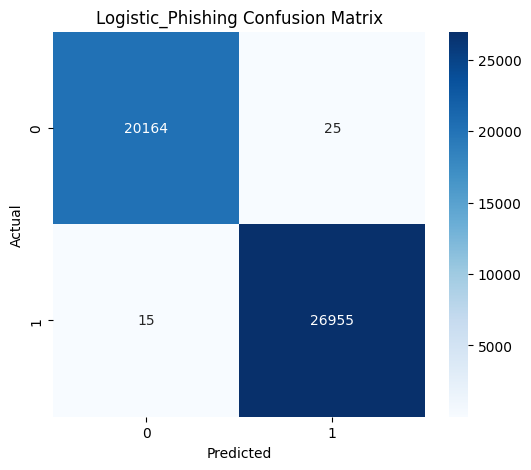

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Logistic_Phishing_confusion.png


(0.9991518055938421, 0.9992585727525487)

In [66]:
log_phish = train_logistic_model(
    X_train_phish,
    y_train_phish
)

evaluate_model(
    log_phish,
    X_test_phish,
    y_test_phish,
    "Logistic_Phishing"
)


Logistic_IDS Results
Accuracy: 0.7159329140461216
F1 Score: 0.6678921568627451


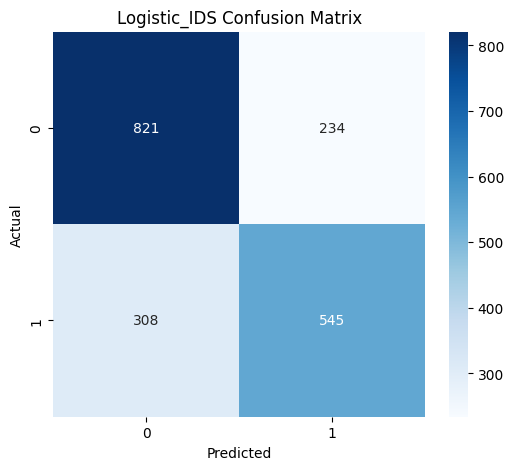

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Logistic_IDS_confusion.png


(0.7159329140461216, 0.6678921568627451)

In [67]:
log_ids = train_logistic_model(
    X_train_ids,
    y_train_ids
)

evaluate_model(
    log_ids,
    X_test_ids,
    y_test_ids,
    "Logistic_IDS"
)


Logistic_Fraud Results
Accuracy: 0.9649122807017544
F1 Score: 0.9652173913043478


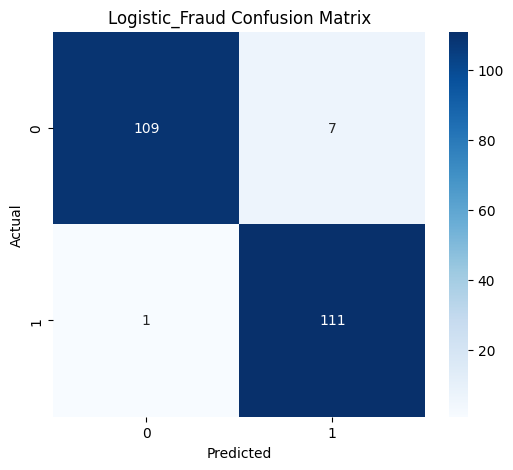

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Logistic_Fraud_confusion.png


(0.9649122807017544, 0.9652173913043478)

In [68]:
log_fraud = train_logistic_model(
    X_train_fraud,
    y_train_fraud
)

evaluate_model(
    log_fraud,
    X_test_fraud,
    y_test_fraud,
    "Logistic_Fraud"
)

In [69]:
# Save Logistic Models
# Save / Load Utilities

def save_pickle(obj, path):
    import pickle
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    import pickle
    with open(path, "rb") as f:
        return pickle.load(f)

print("Save utilities ready")

import pickle
save_pickle(
    log_phish,
    os.path.join(PROJECT_ROOT, "models/base_models/logistic_phish.pkl")
)

save_pickle(
    log_ids,
    os.path.join(PROJECT_ROOT, "models/base_models/logistic_ids.pkl")
)

save_pickle(
    log_fraud,
    os.path.join(PROJECT_ROOT, "models/base_models/logistic_fraud.pkl")
)

print("Logistic models saved successfully")

Save utilities ready
Logistic models saved successfully


In [70]:
results = pd.DataFrame({
    "Dataset": ["Phishing", "IDS", "Fraud"],
    "Model": ["Logistic", "Logistic", "Logistic"],
    "Accuracy": [
        accuracy_score(y_test_phish, log_phish.predict(X_test_phish)),
        accuracy_score(y_test_ids, log_ids.predict(X_test_ids)),
        accuracy_score(y_test_fraud, log_fraud.predict(X_test_fraud))
    ],
    "F1 Score": [
        f1_score(y_test_phish, log_phish.predict(X_test_phish)),
        f1_score(y_test_ids, log_ids.predict(X_test_ids)),
        f1_score(y_test_fraud, log_fraud.predict(X_test_fraud))
    ]
})

results

,Dataset,Model,Accuracy,F1 Score
0,Phishing,Logistic,0.999152,0.999259
1,IDS,Logistic,0.715933,0.667892
2,Fraud,Logistic,0.964912,0.965217


In [71]:
results_path = os.path.join(
    PROJECT_ROOT,
    "logs",
    "logistic_results.csv"
)

results.to_csv(results_path, index=False)

print("Results saved:", results_path)

Results saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/logs/logistic_results.csv


# XGBoost

In [72]:
import xgboost as xgb

def train_xgb_model(X_train, y_train):

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model


XGBoost_Phishing Results
Accuracy: 0.9998939756992302
F1 Score: 0.9999073061307725


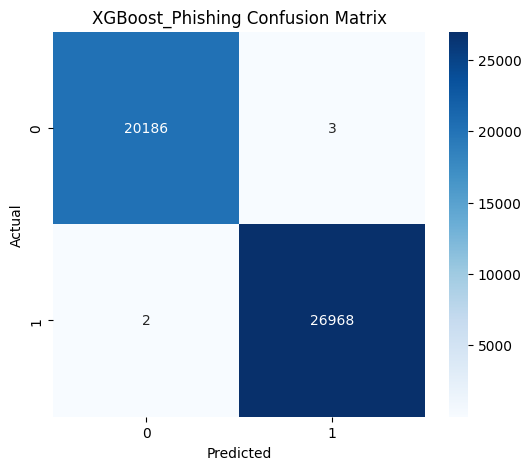

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/XGBoost_Phishing_confusion.png


(0.9998939756992302, 0.9999073061307725)

In [73]:
xgb_phish = train_xgb_model(
    X_train_phish,
    y_train_phish
)

evaluate_model(
    xgb_phish,
    X_test_phish,
    y_test_phish,
    "XGBoost_Phishing"
)


XGBoost_IDS Results
Accuracy: 0.8862683438155137
F1 Score: 0.8542646071188718


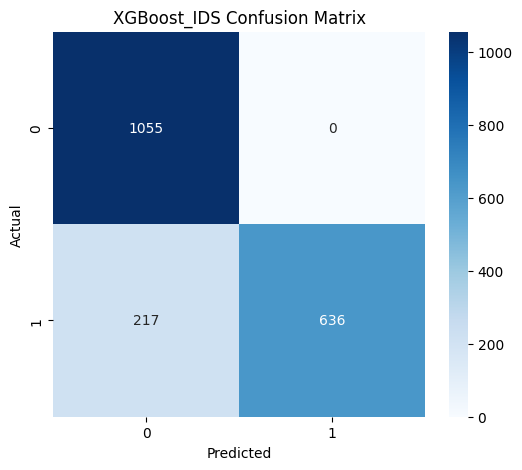

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/XGBoost_IDS_confusion.png


(0.8862683438155137, 0.8542646071188718)

In [74]:
xgb_ids = train_xgb_model(
    X_train_ids,
    y_train_ids
)

evaluate_model(
    xgb_ids,
    X_test_ids,
    y_test_ids,
    "XGBoost_IDS"
)


XGBoost_Fraud Results
Accuracy: 0.9780701754385965
F1 Score: 0.9779735682819384


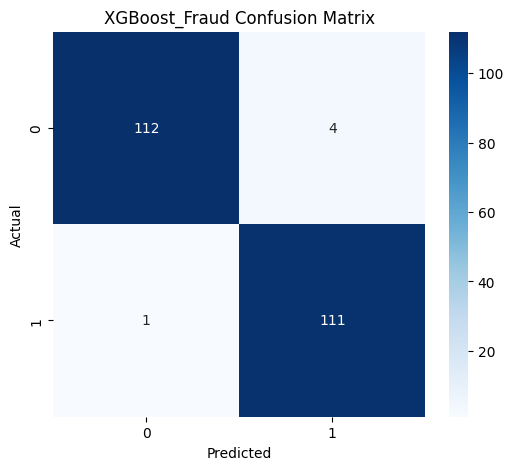

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/XGBoost_Fraud_confusion.png


(0.9780701754385965, 0.9779735682819384)

In [75]:
xgb_fraud = train_xgb_model(
    X_train_fraud,
    y_train_fraud
)

evaluate_model(
    xgb_fraud,
    X_test_fraud,
    y_test_fraud,
    "XGBoost_Fraud"
)

In [76]:
# Save XGBoost Models

save_pickle(
    xgb_phish,
    os.path.join(PROJECT_ROOT, "models/base_models/xgb_phish.pkl")
)

save_pickle(
    xgb_ids,
    os.path.join(PROJECT_ROOT, "models/base_models/xgb_ids.pkl")
)

save_pickle(
    xgb_fraud,
    os.path.join(PROJECT_ROOT, "models/base_models/xgb_fraud.pkl")
)

print("XGBoost models saved successfully")

XGBoost models saved successfully


In [77]:
# XGBoost Results Table

xgb_results = pd.DataFrame({
    "Dataset": ["Phishing", "IDS", "Fraud"],
    "Model": ["XGBoost", "XGBoost", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test_phish, xgb_phish.predict(X_test_phish)),
        accuracy_score(y_test_ids, xgb_ids.predict(X_test_ids)),
        accuracy_score(y_test_fraud, xgb_fraud.predict(X_test_fraud))
    ],
    "F1 Score": [
        f1_score(y_test_phish, xgb_phish.predict(X_test_phish)),
        f1_score(y_test_ids, xgb_ids.predict(X_test_ids)),
        f1_score(y_test_fraud, xgb_fraud.predict(X_test_fraud))
    ]
})

xgb_results

,Dataset,Model,Accuracy,F1 Score
0,Phishing,XGBoost,0.999894,0.999907
1,IDS,XGBoost,0.886268,0.854265
2,Fraud,XGBoost,0.978070,0.977974


In [78]:
results = pd.concat([results, xgb_results], ignore_index=True)

results

,Dataset,Model,Accuracy,F1 Score
0,Phishing,Logistic,0.999152,0.999259
1,IDS,Logistic,0.715933,0.667892
2,Fraud,Logistic,0.964912,0.965217
3,Phishing,XGBoost,0.999894,0.999907
4,IDS,XGBoost,0.886268,0.854265
5,Fraud,XGBoost,0.978070,0.977974


In [79]:
results_path = os.path.join(
    PROJECT_ROOT,
    "logs",
    "baseline_results.csv"
)

results.to_csv(results_path, index=False)

print("Baseline results saved successfully")

Baseline results saved successfully


# Neural Networks

In [80]:
class MLP(nn.Module):

    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [81]:
def train_nn(X_train, y_train, epochs=40):

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

    model = MLP(X_train.shape[1])

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):

        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch} Loss: {loss.item():.4f}")

    return model

In [82]:
def evaluate_nn(model, X_test, y_test, name):

    X_test = torch.tensor(X_test, dtype=torch.float32)

    model.eval()

    with torch.no_grad():
        preds = model(X_test).numpy()

    preds = (preds > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{name} Results")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")

    save_and_show_plot(f"{name}_confusion.png")

    return acc, f1

## For phish

Epoch 0 Loss: 0.7218
Epoch 5 Loss: 0.5186
Epoch 10 Loss: 0.3426
Epoch 15 Loss: 0.2051

NN_Phishing Results
Accuracy: 0.9861108165991646
F1 Score: 0.9877375269119161


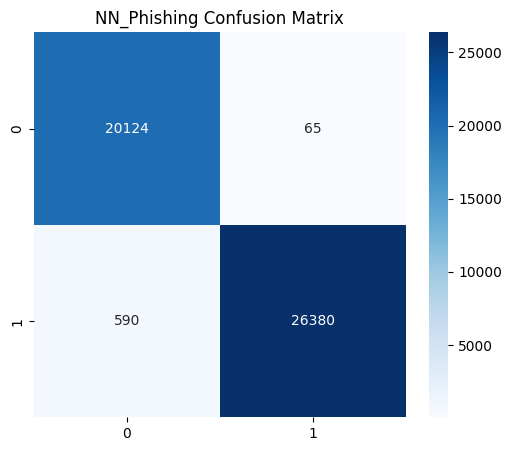

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/NN_Phishing_confusion.png


In [83]:
nn_phish = train_nn(
    X_train_phish,
    y_train_phish,
    epochs=20
)

acc_phish_nn, f1_phish_nn = evaluate_nn(
    nn_phish,
    X_test_phish,
    y_test_phish,
    "NN_Phishing"
)

## For IDS

Epoch 0 Loss: 0.6962
Epoch 5 Loss: 0.5829
Epoch 10 Loss: 0.5106
Epoch 15 Loss: 0.4815

NN_IDS Results
Accuracy: 0.700733752620545
F1 Score: 0.7085247575293517


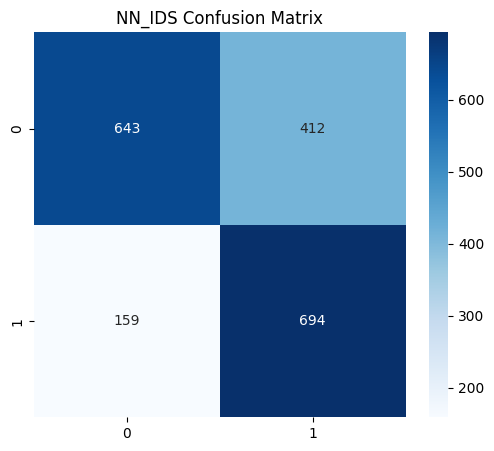

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/NN_IDS_confusion.png


In [84]:
nn_ids = train_nn(
    X_train_ids,
    y_train_ids,
    epochs=20
)

acc_ids_nn, f1_ids_nn = evaluate_nn(
    nn_ids,
    X_test_ids,
    y_test_ids,
    "NN_IDS"
)

## Improved IDS

In [85]:
class MLP_IDS(nn.Module):

    def __init__(self, input_dim):
        super(MLP_IDS, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [86]:
print("IDS Train Distribution:")
print(pd.Series(y_train_ids).value_counts())

print("\nIDS Test Distribution:")
print(pd.Series(y_test_ids).value_counts())

IDS Train Distribution:
0    4218
1    3411
Name: count, dtype: int64

IDS Test Distribution:
0    1055
1     853
Name: count, dtype: int64


In [87]:
def train_nn_ids(X_train, y_train, epochs=40, batch_size=32):

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

    dataset = torch.utils.data.TensorDataset(X_train, y_train)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = MLP(X_train.shape[1])

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)  # smaller LR for small dataset

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X_batch, y_batch in loader:

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 5 == 0:
            print(f"Epoch {epoch} Loss: {total_loss:.4f}")

    return model

Epoch 0 Loss: 122.6237
Epoch 5 Loss: 98.9200
Epoch 10 Loss: 94.4734
Epoch 15 Loss: 92.0134
Epoch 20 Loss: 90.0844
Epoch 25 Loss: 88.4484
Epoch 30 Loss: 90.4594
Epoch 35 Loss: 87.5689

NN_IDS_Improved Results
Accuracy: 0.870020964360587
F1 Score: 0.8331090174966352


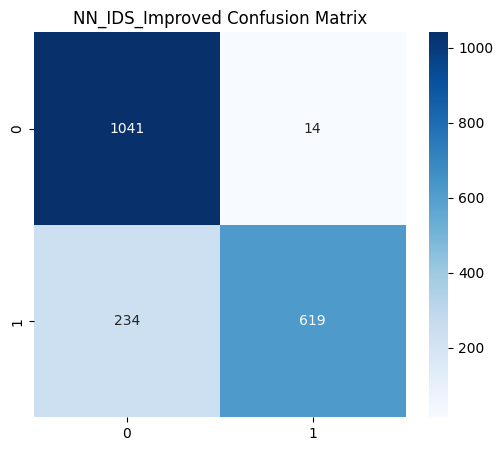

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/NN_IDS_Improved_confusion.png


In [88]:
nn_ids = train_nn_ids(
    X_train_ids,
    y_train_ids
)

acc_ids_nn, f1_ids_nn = evaluate_nn(
    nn_ids,
    X_test_ids,
    y_test_ids,
    "NN_IDS_Improved"
)

## For Fraud

Epoch 0 Loss: 0.6985
Epoch 5 Loss: 0.5126
Epoch 10 Loss: 0.3771
Epoch 15 Loss: 0.2749

NN_Fraud Results
Accuracy: 0.9298245614035088
F1 Score: 0.9327731092436975


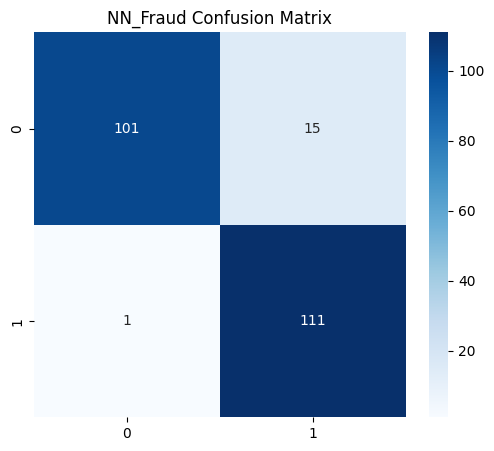

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/NN_Fraud_confusion.png


In [89]:
nn_fraud = train_nn(
    X_train_fraud,
    y_train_fraud,
    epochs=20
)

acc_fraud_nn, f1_fraud_nn = evaluate_nn(
    nn_fraud,
    X_test_fraud,
    y_test_fraud,
    "NN_Fraud"
)

## Saving

In [90]:
torch.save(
    nn_phish.state_dict(),
    os.path.join(PROJECT_ROOT, "models/base_models/nn_phish.pt")
)

torch.save(
    nn_ids.state_dict(),
    os.path.join(PROJECT_ROOT, "models/base_models/nn_ids.pt")
)

torch.save(
    nn_fraud.state_dict(),
    os.path.join(PROJECT_ROOT, "models/base_models/nn_fraud.pt")
)

print("Neural network models saved")

Neural network models saved


In [91]:
torch.save(
    nn_ids.state_dict(),
    os.path.join(PROJECT_ROOT, "models/base_models/nn_ids_improved.pt")
)

print("Improved IDS model saved")

Improved IDS model saved


In [92]:
nn_results = pd.DataFrame({
    "Dataset": ["Phishing", "IDS", "Fraud"],
    "Model": ["NeuralNet", "NeuralNet", "NeuralNet"],
    "Accuracy": [
        acc_phish_nn,
        acc_ids_nn,   # improved IDS value already stored
        acc_fraud_nn
    ],
    "F1 Score": [
        f1_phish_nn,
        f1_ids_nn,    # improved IDS value already stored
        f1_fraud_nn
    ]
})

# Remove old NeuralNet rows first (avoid duplicates)
results = results[results["Model"] != "NeuralNet"]

# Append updated NeuralNet results
results = pd.concat([results, nn_results], ignore_index=True)

results

,Dataset,Model,Accuracy,F1 Score
0,Phishing,Logistic,0.999152,0.999259
1,IDS,Logistic,0.715933,0.667892
2,Fraud,Logistic,0.964912,0.965217
3,Phishing,XGBoost,0.999894,0.999907
4,IDS,XGBoost,0.886268,0.854265
5,Fraud,XGBoost,0.978070,0.977974
6,Phishing,NeuralNet,0.986111,0.987738
7,IDS,NeuralNet,0.870021,0.833109
8,Fraud,NeuralNet,0.929825,0.932773


Dataset	Model	Accuracy	F1 Score
0	Phishing	Logistic	0.999873	0.999889
1	IDS	Logistic	0.715933	0.667892
2	Fraud	Logistic	0.964912	0.965217
3	Phishing	XGBoost	1.000000	1.000000
4	IDS	XGBoost	0.886268	0.854265
5	Fraud	XGBoost	0.978070	0.977974
6	Phishing	NeuralNet	0.994529	0.995201
7	IDS	NeuralNet	0.864256	0.827907
8	Fraud	NeuralNet	0.872807	0.883534

In [94]:
results.to_csv(
    os.path.join(PROJECT_ROOT, "logs/baseline_results.csv"),
    index=False
)